outline image saved as exractimage.png


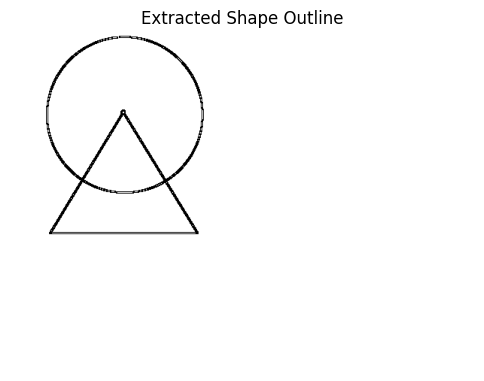

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def manual_threshold(image, threshold=128):
    """Apply manual thresholding without OpenCV functions."""
    height, width = image.shape
    binary = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            if image[i, j] < threshold:
                binary[i, j] = 255  # Foreground (Shape)
            else:
                binary[i, j] = 0  # Background
    return binary

def sobel_edge_detection(image):
    """Manually compute Sobel edge detection."""
    height, width = image.shape
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])  # X-direction
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])  # Y-direction

    edge_image = np.zeros((height, width), dtype=np.uint8)

    # Apply Sobel filter manually
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            gx = np.sum(image[i - 1:i + 2, j - 1:j + 2] * sobel_x)
            gy = np.sum(image[i - 1:i + 2, j - 1:j + 2] * sobel_y)
            edge_magnitude = np.sqrt(gx**2 + gy**2)

            if edge_magnitude > 100:  # Edge threshold
                edge_image[i, j] = 255  # Edge detected

    return edge_image

def find_largest_contour(binary):
    """Find and return the largest contour from a binary image."""
    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        """Follow the contour edges."""
        stack = [(x, y)]
        contour = []
        while stack:
            cx, cy = stack.pop()
            if 0 <= cx < height and 0 <= cy < width and not visited[cx, cy] and binary[cx, cy] == 255:
                visited[cx, cy] = True
                contour.append((cx, cy))
                stack.extend([(cx-1, cy), (cx+1, cy), (cx, cy-1), (cx, cy+1)])
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:  # Remove small contours (text)
                    contours.append(contour)

    if contours:
        return max(contours, key=len)  # Largest contour
    return None

def extract_shape_outline(image_path):
    """Extract only the shape outline while removing text."""
    # Load grayscale image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Error: Image not found")
        return

    # Invert image (so shapes become dark on a light background)
    image = 255 - image

    # Apply manual thresholding
    binary = manual_threshold(image, threshold=150)

    # Apply Sobel edge detection
    edges = sobel_edge_detection(binary)

    # Find largest contour
    largest_contour = find_largest_contour(edges)
    if largest_contour is None:
        print("No valid contour found")
        return

    # Create a blank image with white background
    outline_image = np.ones_like(image) * 255  # White background

    # Draw the largest contour as black outline
    for x, y in largest_contour:
        outline_image[x, y] = 0  # Black outline

    outlineImagePath = "exractimage.png"
    cv2.imwrite(outlineImagePath, outline_image)
    print(f"outline image saved as {outlineImagePath}")

    # Display the extracted shape outline
    plt.figure(figsize=(6, 6))
    plt.imshow(outline_image, cmap='gray')
    plt.title("Extracted Shape Outline")
    plt.axis("off")
    plt.show()

# Example usage
image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\AlltheStepsInOne\step3_text_removed.png"
extract_shape_outline(image_path)
